**Column Details:**

1. **mpg**: Miles per gallon, a measure of fuel efficiency.
2. **cylinders**: Number of cylinders in the car's engine.
3. **displacement**: Engine displacement in cubic inches.
4. **horsepower**: Engine power output, typically in horsepower units.
5. **weight**: Vehicle weight in pounds.
6. **acceleration**: Time (in seconds) to accelerate from 0 to 60 mph.
7. **model year**: Year the car model was manufactured.
8. **origin**: Region where the car was manufactured (1=USA, 2=Europe, 3=Asia).
9. **car name**: Name and model of the car.

In [1]:
# importing important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from keras import layers

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'/content/car_mpg_efficiency.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
df.shape

(398, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


We can see horse power and car name is in object format, car name is fine as it is but horsepower has to be in int or float type so we need to convert it from string to integer or float.

Though we see no null values in the dataset we need to be sure.

In [5]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

When we observe closely we have a '?' in this column, this is one of the null values we can either fill it with mean mode or simply remove them.

In this example we will be removing them.

In [6]:
q = df[df['horsepower'] == '?']
print(len(q))

6


We have only 6 values with '?' i.e is the null values. So we'll be just removing them.

In [7]:
print(df.shape)
df = df[df['horsepower'] != '?']
print(df.shape)

(398, 9)
(392, 9)


In [8]:
df['horsepower'] = df['horsepower'].astype(int)
df['horsepower'].dtype

dtype('int64')

In [9]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [10]:
df.nunique()

,0
mpg,127
cylinders,5
displacement,81
horsepower,93
weight,346
acceleration,95
model year,13
origin,3
car name,301


Let's visualize our data.

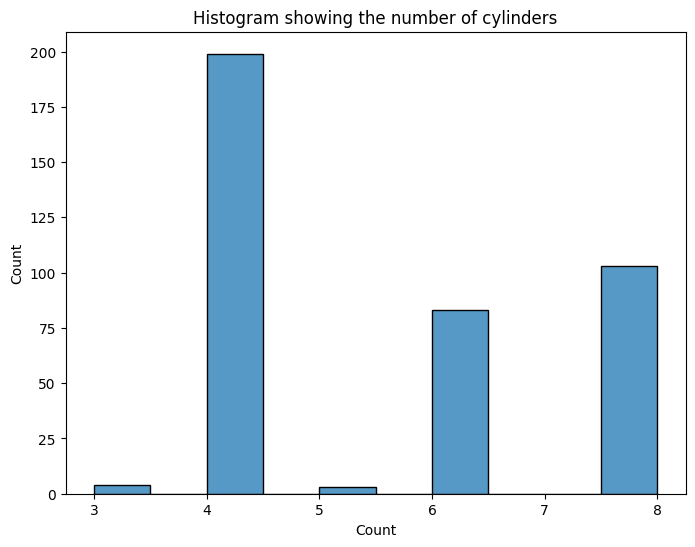

In [11]:
plt.figure(figsize=(8,6))
sns.histplot(df['cylinders'])
plt.title("Histogram showing the number of cylinders")
plt.xlabel("Cylinders")
plt.xlabel("Count")
plt.show()

From above graph we see that most of the cars are of 4 cylinders.

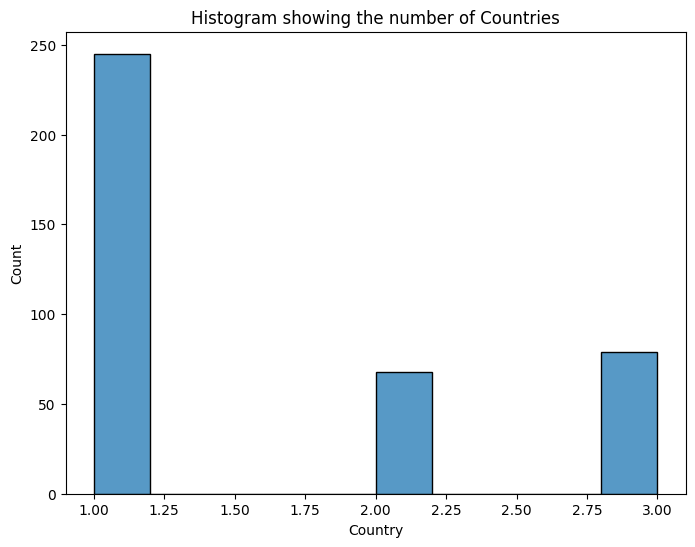

In [12]:
plt.figure(figsize=(8,6))
sns.histplot(df['origin'])
plt.title("Histogram showing the number of Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

1 : USA,
2 : EUROPE,
3 : ASIA

We infer that most number of cars are from USA origins and least from EUROPE

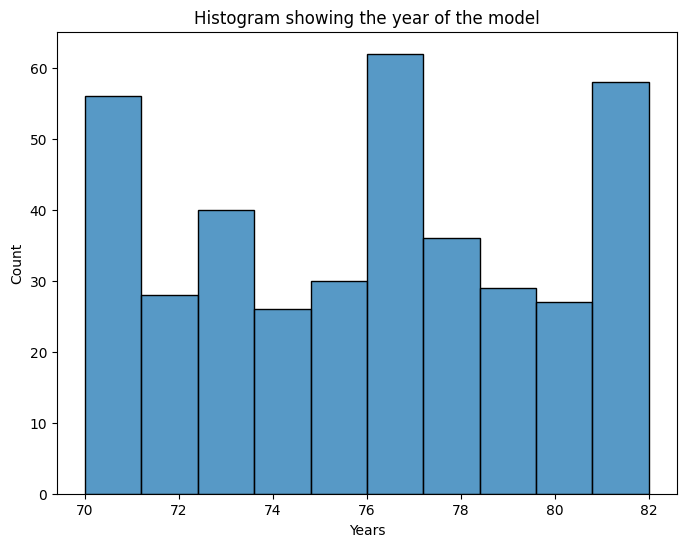

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(df['model year'])
plt.title("Histogram showing the year of the model")
plt.xlabel("Years")
plt.ylabel("Count")
plt.show()

Here we can infer that most of the cars were manufactured in the year 77 followed by 82 and 70.

---

Let's check for Correlation among the columns.

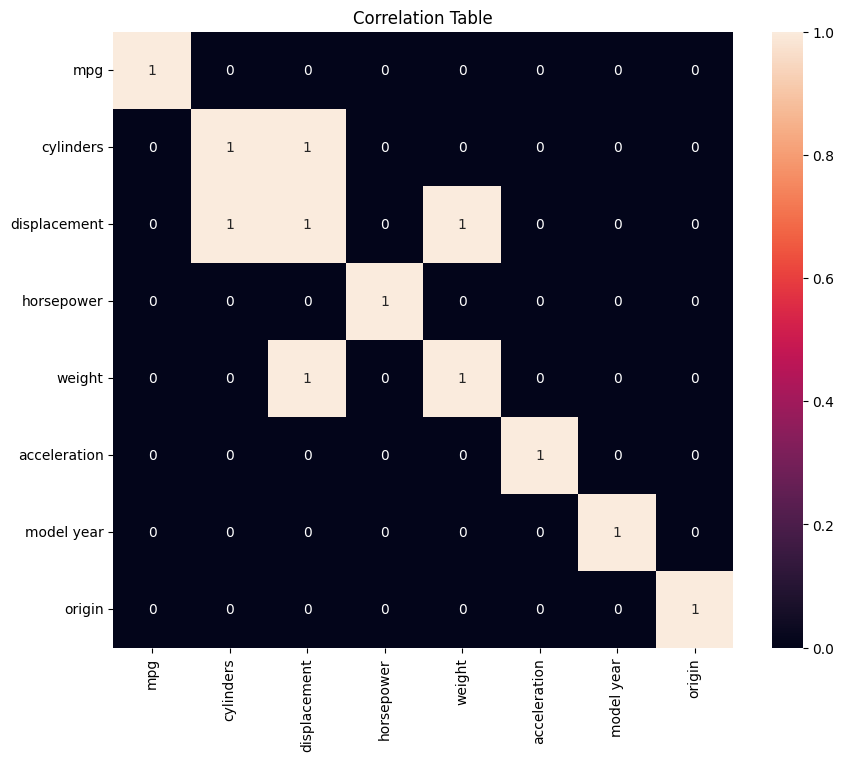

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True)>0.9, annot=True)
plt.title("Correlation Table")
plt.show()

We'll be removing displacement because it is highly corelated with cylinders and weight.

In [15]:
df.drop('displacement', axis=1, inplace=True)

In [16]:
df.columns

Index(['mpg', 'cylinders', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin', 'car name'],
      dtype='object')

displacement has been removed.

In [17]:
from sklearn.model_selection import train_test_split

x = df.drop(['mpg', 'car name'], axis=1)
y = df['mpg']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((313, 6), (79, 6), (313,), (79,))

In [18]:
AUTO = tf.data.experimental.AUTOTUNE

train_ds = (tf.data.Dataset
            .from_tensor_slices((x_train, y_train))
            .batch(32)
            .prefetch(AUTO))

test_ds = (tf.data.Dataset
          .from_tensor_slices((x_test, y_test))
          .batch(32)
          .prefetch(AUTO))

In [19]:
# Model Architecture

model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=[6]),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation='relu')
])

In [20]:
# model compilation

model.compile(
    loss = 'mae',
    optimizer = 'adam',
    metrics = ['mape']
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,889 (273.00 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [22]:
#model training

history = model.fit(train_ds,
                    epochs = 50,
                    validation_data=test_ds)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 22.4870 - mape: 95.8383 - val_loss: 22.7962 - val_mape: 99.8701
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20.5072 - mape: 89.9529 - val_loss: 22.8380 - val_mape: 100.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 18.7577 - mape: 84.2883 - val_loss: 22.8380 - val_mape: 100.0000
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 17.1408 - mape: 78.8864 - val_loss: 22.8380 - val_mape: 100.0000
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 15.7225 - mape: 73.8447 - val_loss: 22.8380 - val_mape: 100.0000
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.2556 - mape: 68.6824 - val_loss: 22.8380 - val_mape: 100.0000
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 12.8793 - mape: 63.8891 - val_loss: 22.8380 - val_mape: 100.0000
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.7284 - mape: 59.2601 - val_loss: 22.6715 - val_mape: 99.4696
Epoch 9/50

In [23]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mape,val_loss,val_mape
0,22.264668,94.621490,22.796183,99.870094
1,20.238546,88.673996,22.837975,100.000000
2,18.458115,82.790192,22.837975,100.000000
3,16.978157,77.949921,22.837975,100.000000
4,15.568006,72.931076,22.837975,100.000000


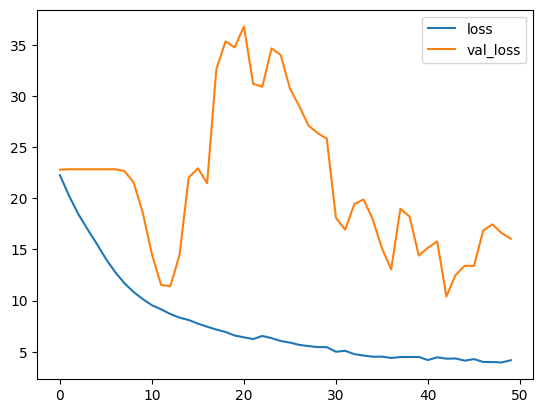

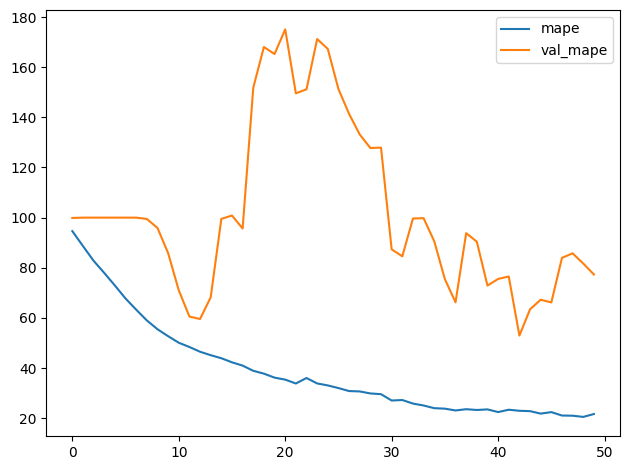

In [24]:
history_df.loc[:,['loss','val_loss']].plot()
history_df.loc[:,['mape','val_mape']].plot()
plt.tight_layout()
plt.show()

Thank you for going through my work till the end, feel free to get in touch if you have any questions.